# 02 — Evidence: problems in the manual optical log (and other data issues)

**Question:** the optical crown temperature (`Melter Optical Temperature` in the analytical record) has missing days, duplicate readings and odd values. Are these random, or do they have a cause we can prove?

**Source:** only `data/raw/Analytical_Record_Creation_EE_60TPD_updated-2.xlsx`, sheet `result`. The client baseline workbook is used once (§6), clearly marked, only to *verify* the draw fix.

**Short answer:** two systematic date/time errors, both proven below.
1. **Day and month swapped (DD/MM ↔ MM/DD)** for log dates with day ≤ 12.
2. **12-hour clock in 6 months of 2026** (Jan, Mar, Apr, Jun, Aug, Sep): readings from 13:00–23:00 were stored at 01:00–11:00.

In [1]:
import sys; sys.path.insert(0, '../src')
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import data_prep as dp
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40)
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, INK2, MUTED, GRID, SURF = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#fcfcfb'
plt.rcParams.update({'figure.facecolor': SURF, 'axes.facecolor': SURF, 'axes.edgecolor': MUTED,
    'axes.labelcolor': INK2, 'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.grid': True,
    'grid.color': GRID, 'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'lines.linewidth': 1.6, 'font.size': 10, 'axes.titlesize': 11, 'axes.titlecolor': INK,
    'legend.frameon': False, 'figure.dpi': 110})
raw = dp.load_ar_raw()
slot = raw.groupby('ts')['opt_temp'].agg(n_rows='size', n_read='count')
# The optical log uses a 06:00-06:00 shift day (missing blocks start/stop at 06:00)
slot['shift_day'] = (slot.index - pd.Timedelta(hours=6)).normalize()
slot['hour'] = slot.index.hour
print('15-min slots:', len(slot), '| slots with 0 readings:', (slot.n_read==0).sum(), '| with 2 readings:', (slot.n_rows>1).sum())

15-min slots: 37920 | slots with 0 readings: 13180 | with 2 readings: 5472


## 1. Picture of the problem: one row per day, one column per hour
Colour = number of optical readings stored in that hour (0 = missing, 1 = normal, 2 = duplicate).
- The **white horizontal bands** are whole days missing.
- The **orange/white blocks in 2026** are the 12-hour clock. In those months the left half (01–12 h) is doubled and the right half (13–24 h) is empty. February, May and July 2026 are full blue, so they are logged correctly.

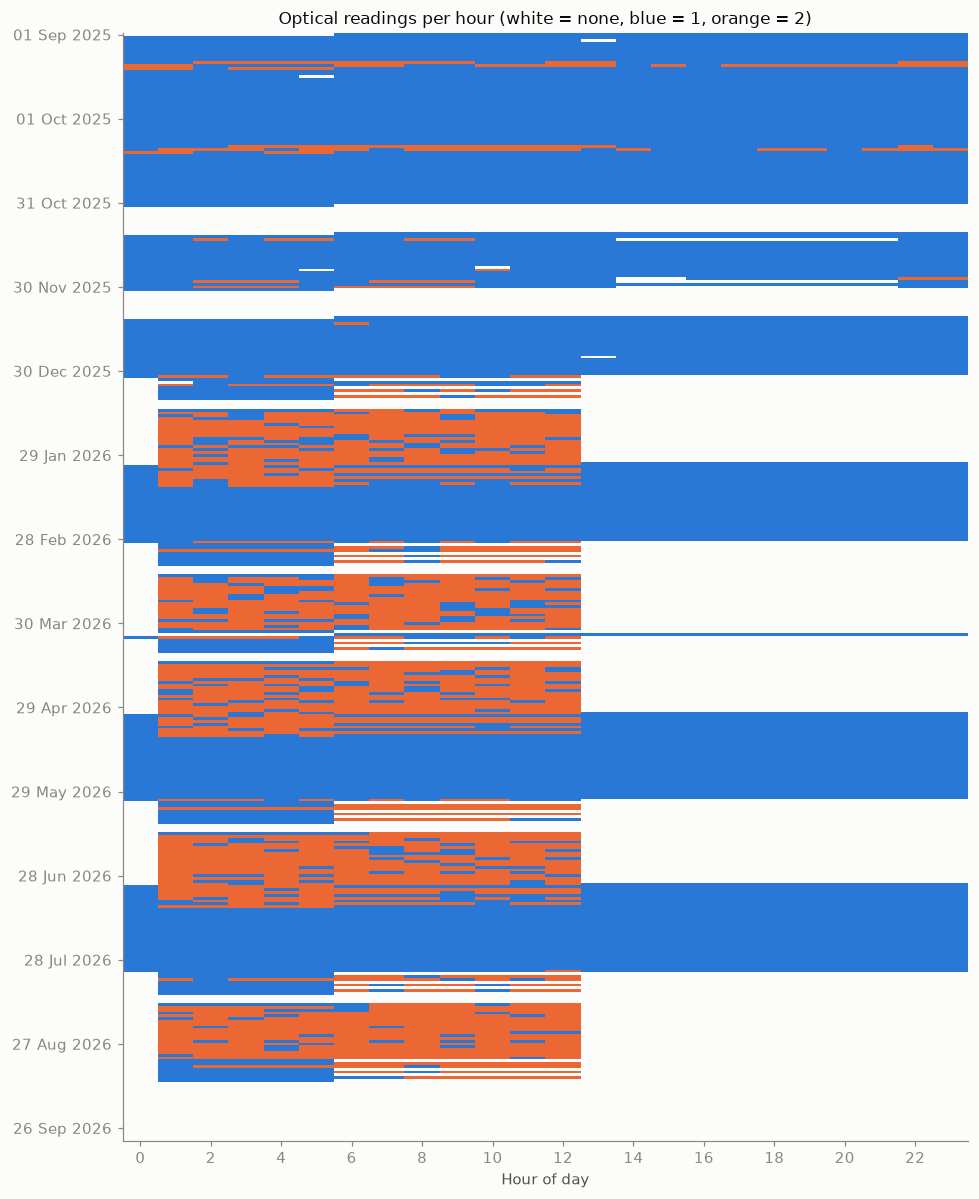

In [2]:
hr = slot.groupby([slot.index.normalize(), 'hour'])['n_rows'].max().where(
        slot.groupby([slot.index.normalize(), 'hour'])['n_read'].max() > 0, 0).unstack()
from matplotlib.colors import ListedColormap
cmap = ListedColormap([SURF, BLUE, ORANGE])
fig, ax = plt.subplots(figsize=(9, 11))
ax.imshow(hr.values, aspect='auto', cmap=cmap, vmin=0, vmax=2, interpolation='nearest')
yt = np.arange(0, len(hr), 30); ax.set_yticks(yt); ax.set_yticklabels([hr.index[i].strftime('%d %b %Y') for i in yt])
ax.set_xticks(range(0, 24, 2)); ax.set_xlabel('Hour of day'); ax.grid(False)
ax.set_title('Optical readings per hour (white = none, blue = 1, orange = 2)')
plt.tight_layout(); plt.show()

## 2. Proof 1: day and month were swapped (DD/MM ↔ MM/DD)

**How it happens:** the log date `09/11/2025` means 9 Nov in DD/MM. If it is read as MM/DD it becomes 11 Sep. Then:
- 9 Nov loses its readings, so it shows as **missing**.
- 11 Sep gets a second set of readings, so it shows as **duplicated**.
- If the swapped date falls outside the data period (for example `05/11/2025` → 11 May 2025), the readings are simply lost.

**Test:** for every fully missing shift-day with day ≤ 12, compute its swapped date (month ↔ day).
- **Prediction:** a swapped date inside the data period must carry duplicates; one outside the period can't be checked.
- **Control:** compare with how often *other* days with day ≤ 12 have duplicates.

In [3]:
day = slot.groupby('shift_day').agg(slots=('n_rows','size'), have=('n_read', lambda s: (s>0).sum()),
                                    dup=('n_rows', lambda s: (s>1).sum()))
day = day[(day.index >= '2025-09-01') & (day.index <= '2026-09-30')]
start, end = day.index.min(), day.index.max()
TAIL = pd.Timestamp('2026-09-09')      # optical stops completely from here (separate issue)
missing = day[(day.have == 0) & (day.index < TAIL)]
rows = []
for dte in missing.index:
    swapped = pd.Timestamp(year=dte.year, month=dte.day, day=dte.month) if dte.day <= 12 else None
    inside = swapped is not None and start <= swapped <= end
    rows.append(dict(missing_day=dte.date(), day_of_month=dte.day,
                     swapped_date=None if swapped is None else swapped.date(),
                     swapped_inside_period=inside,
                     extra_readings_on_swapped=int(day.dup.get(swapped, 0)) if inside else None))
proof = pd.DataFrame(rows)
proof

,missing_day,day_of_month,swapped_date,swapped_inside_period,extra_readings_on_swapped
0,2025-11-01,1,2025-01-11,False,NaN
1,2025-11-02,2,2025-02-11,False,NaN
2,2025-11-03,3,2025-03-11,False,NaN
3,2025-11-04,4,2025-04-11,False,NaN
4,2025-11-05,5,2025-05-11,False,NaN
5,2025-11-06,6,2025-06-11,False,NaN
6,2025-11-07,7,2025-07-11,False,NaN
7,2025-11-08,8,2025-08-11,False,NaN
8,2025-11-09,9,2025-09-11,True,40.0
9,2025-11-10,10,2025-10-11,True,52.0


In [4]:
print('Fully missing days (before the Sep-2026 tail):', len(proof))
print('  of which day-of-month <= 12:', (proof.day_of_month <= 12).sum(), ' | day-of-month > 12:', (proof.day_of_month > 12).sum())
ins = proof[proof.swapped_inside_period]
print('Swapped date inside the period:', len(ins), '-> carries duplicates:', (ins.extra_readings_on_swapped > 0).sum())
targets = set(pd.to_datetime(ins.swapped_date))
ctrl = day[(day.index.day <= 12) & ~day.index.isin(targets) & ~day.index.isin(missing.index) & (day.index < TAIL)]
for name, c in [('all', ctrl), ('2025 only (no 12-h clock effect)', ctrl[ctrl.index < '2026-01-01'])]:
    rate = (c.dup > 0).mean()
    print('Control (%s): other day<=12 dates carrying duplicates: %d of %d (%.0f%%)' % (name, (c.dup>0).sum(), len(c), 100*rate))
rate_all = (ctrl.dup > 0).mean()
print('Chance that all %d predicted dates carry duplicates if it were random: %.1e' % (len(ins), rate_all ** len(ins)))

Fully missing days (before the Sep-2026 tail): 36
  of which day-of-month <= 12: 36  | day-of-month > 12: 0
Swapped date inside the period: 10 -> carries duplicates: 10
Control (all): other day<=12 dates carrying duplicates: 51 of 106 (48%)
Control (2025 only (no 12-h clock effect)): other day<=12 dates carrying duplicates: 3 of 24 (12%)
Chance that all 10 predicted dates carry duplicates if it were random: 6.6e-04


**Reading the result:**
- Every fully missing day has day-of-month ≤ 12; no day 13–31 is ever lost.
- Every missing day whose swapped date falls inside the period has duplicate readings on exactly that swapped date.
- In 2025, only about one in eight other day ≤ 12 dates have duplicates. Over the whole period the control rate is higher, because the 12-hour clock adds duplicates in some 2026 months. Even at that higher rate, getting 10 out of 10 by chance is very unlikely (see the printed probability).

This is what a DD/MM ↔ MM/DD mix-up produces, and nothing else explains why only days 1–12 go missing.

When both dates of a pair are valid (for example 4 Mar ↔ 3 Apr), nothing goes missing; the readings are moved to the other date and show up as duplicates there. The next cell lists such pairs. This is *supporting* evidence only, because in some 2026 months the 12-hour clock also creates duplicates.

In [5]:
pairs = []
for dte in day.index[(day.index.day <= 12) & (day.dup > 0)]:
    sw = pd.Timestamp(year=dte.year, month=dte.day, day=dte.month)
    if sw != dte and start <= sw <= end and sw < dte:
        pairs.append(dict(date_a=dte.date(), date_b=sw.date(), dup_a=int(day.dup[dte]), dup_b=int(day.dup.get(sw, 0))))
pairs = pd.DataFrame(pairs)
print('Pairs (d/m <-> m/d) where both dates exist:', len(pairs), '| both carry duplicates:', ((pairs.dup_a>0)&(pairs.dup_b>0)).sum())
pairs.head(20)

Pairs (d/m <-> m/d) where both dates exist: 26 | both carry duplicates: 13


,date_a,date_b,dup_a,dup_b
0,2026-02-01,2026-01-02,44,0
1,2026-03-01,2026-01-03,16,16
2,2026-04-01,2026-01-04,20,16
3,2026-04-03,2026-03-04,16,20
4,2026-05-01,2026-01-05,40,0
5,2026-05-02,2026-02-05,16,20
6,2026-05-03,2026-03-05,48,0
7,2026-05-04,2026-04-05,44,0
8,2026-06-01,2026-01-06,12,20
9,2026-06-03,2026-03-06,48,24


## 3. Proof 2: 12-hour clock in some months of 2026
If AM/PM is lost, a reading taken at 15:00 is stored at 03:00. In an affected month:
- hours 13–23 should be (almost) empty
- hours 01–12 should carry two readings in about half the slots

The check is done month by month.

In [6]:
s = slot.copy(); s['month'] = s.index.to_period('M')
pm = s[s.hour >= 13]; am = s[(s.hour >= 1) & (s.hour <= 12)]
by_m = pd.DataFrame({'pm_coverage (13-23 h)': pm.groupby('month').n_read.apply(lambda x: (x>0).mean()),
                     'am_coverage (01-12 h)': am.groupby('month').n_read.apply(lambda x: (x>0).mean()),
                     'am_duplicates (01-12 h)': am.groupby('month').n_rows.apply(lambda x: (x>1).mean())})
q_tmp = dp.clean_15min(with_crown=False)
by_m['12-h clock month (rule)'] = by_m.index.isin(dp.ampm_months(q_tmp))
by_m.round(2)

,pm_coverage (13-23 h),am_coverage (01-12 h),am_duplicates (01-12 h),12-h clock month (rule)
month,,,,
2025-09,1.00,0.98,0.05,False
2025-10,1.00,1.00,0.06,False
2025-11,0.59,0.66,0.05,False
2025-12,0.67,0.68,0.00,False
2026-01,0.00,0.83,0.55,True
2026-02,1.00,1.00,0.20,False
2026-03,0.00,0.83,0.56,True
2026-04,0.03,0.81,0.54,True
2026-05,1.00,1.00,0.19,False


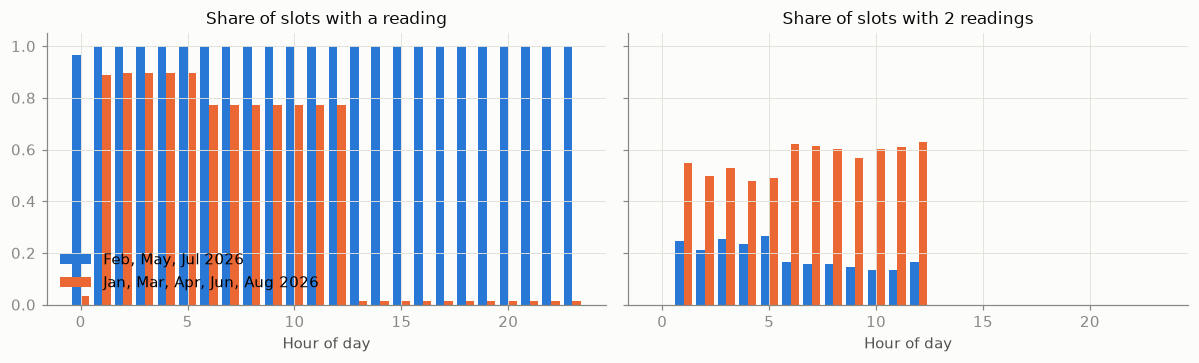

In [7]:
ok = s[s.month.isin([pd.Period('2026-02'), pd.Period('2026-05'), pd.Period('2026-07')])]
bad = s[s.month.isin([pd.Period(m) for m in ['2026-01','2026-03','2026-04','2026-06','2026-08']])]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for a_, fn, ttl in [(ax[0], lambda x: (x.n_read>0).mean(), 'Share of slots with a reading'), (ax[1], lambda x: (x.n_rows>1).mean(), 'Share of slots with 2 readings')]:
    a_.bar(np.arange(24) - 0.2, ok.groupby('hour').apply(fn), width=0.4, color=BLUE, label='Feb, May, Jul 2026')
    a_.bar(np.arange(24) + 0.2, bad.groupby('hour').apply(fn), width=0.4, color=ORANGE, label='Jan, Mar, Apr, Jun, Aug 2026')
    a_.set_title(ttl); a_.set_xlabel('Hour of day')
ax[0].legend(loc='lower left'); plt.tight_layout(); plt.show()

**Reading the result:**
- In Jan, Mar, Apr, Jun, Aug and Sep 2026, hours 13–23 have essentially no readings and about 55% of the 01–12 h slots are doubled.
- In Feb, May and Jul 2026 (and all of 2025), all 24 hours are filled.

So in the affected months every afternoon/evening reading was stored 12 hours early. The daily mean for those months is still correct (the readings stay on the same day), but the hour of each reading is wrong. This looks like those monthly logs were saved in a different date/time format.

## 4. What a duplicated slot looks like

In [8]:
ex = raw[(raw.ts >= '2026-03-20 06:00') & (raw.ts < '2026-03-20 14:00')].groupby('ts')['opt_temp'].apply(list)
ex.to_frame('optical readings stored at this time')

,optical readings stored at this time
ts,
2026-03-20 06:00:00,"[1574.0, 1575.0]"
2026-03-20 06:15:00,"[1574.0, 1575.0]"
2026-03-20 06:30:00,"[1574.0, 1575.0]"
2026-03-20 06:45:00,"[1574.0, 1575.0]"
2026-03-20 07:00:00,[1575.0]
2026-03-20 07:15:00,[1575.0]
2026-03-20 07:30:00,[1575.0]
2026-03-20 07:45:00,[1575.0]
2026-03-20 08:00:00,"[1574.0, 1575.0]"


Two different plausible readings (e.g. 1575 and 1570) are stored under the same timestamp. Averaging them, which is what notebook 01 does, mixes two different hours or two different days.

## 5. Typing errors in the optical log

In [9]:
bad = raw.loc[raw.opt_temp.notna() & ~raw.opt_temp.between(1550, 1600), ['ts', 'opt_temp']]
bad.groupby('opt_temp').ts.agg(['count', 'min']).rename(columns={'count': 'rows', 'min': 'first seen'})

,rows,first seen
opt_temp,,
1473.0,4,2026-07-23 07:00:00
1475.0,8,2025-12-16 01:00:00
1476.0,4,2025-12-21 11:00:00
1674.0,4,2025-10-03 12:00:00
2576.0,4,2025-10-01 16:00:00
15722.0,4,2025-11-27 02:00:00
15757.0,4,2025-10-23 19:00:00


These look like keying errors of ~1575 (extra or missing digit, 1↔2, 5↔4), consistent with hand typing. Rule: values outside 1,550–1,600 °C → missing.

## 6. Other data issues (proof)
**Draw doubled on two days.** On 2025-10-01 and 2026-06-01 the record's draw is about double the surrounding days. The cleaning code detects this (more than 1.6× the median of the surrounding week) and halves it.
*Verification only:* the client workbook's SAP draw is used here to check the halved value; it is not used to fill data.

In [10]:
d_raw = raw.groupby(raw.ts.dt.normalize())['draw_kg'].first()
ref = d_raw.rolling(7, center=True, min_periods=3).median()
flag = d_raw[d_raw > 1.6 * ref]
base = dp.load_baseline_daily()  # verification only
pd.DataFrame({'record_draw': flag, 'week_median': ref[flag.index], 'ratio': (flag / ref[flag.index]).round(2),
              'halved': flag / 2, 'client_SAP_draw (check)': base.base_draw_kg.reindex(flag.index)})

,record_draw,week_median,ratio,halved,client_SAP_draw (check)
ts,,,,,
2025-10-01,106204.0,55178.0,1.92,53102.0,53102
2026-06-01,115858.0,57807.0,2.00,57929.0,57929


**NCV meter.** It reads 0 from 1 Sep to 6 Oct 2025 and is missing for short periods after that (notebook 01 §3). Per the user's decision, those rows and days are left out (`ncv_ok`).

## 7. Consequences and rules used from here on
| Issue | Rule in `src/data_prep.py` | Effect on modelling |
|---|---|---|
| Date swap (days 1–12) | `opt_day_ok = False` for days ≤ 12 with duplicates, or < 50% coverage | Daily optical mean is used only on `opt_day_ok` days |
| 12-hour clock (6 months of 2026) | `opt_ampm_month` detected from the data; `opt_hour_ok = False` in those months and on duplicate slots | **Hourly optical is not usable in those months.** The hourly crown temperature signal is the **TC MC3** thermocouple (1-min DCS, clean) |
| Typing errors | outside 1,550–1,600 °C → NaN | – |
| Draw doubled | halved automatically (`draw_fixed`) | Verified exactly against SAP |

**In live use** this doesn't matter. The operator types the current optical reading into the recommender, so the date and time are correct at entry.

**Ask the plant:** export the original optical log with ISO dates (YYYY-MM-DD) and a 24-hour clock. That would let us repair the history instead of dropping it.

In [11]:
q = dp.clean_15min(); d = dp.build_daily(q)
print('Days with trustworthy daily optical mean:', int(d.opt_day_ok.sum()), 'of', len(d))
print('15-min slots with trustworthy hourly position:', int(q.opt_hour_ok.sum()), 'of', len(q))

Days with trustworthy daily optical mean: 255 of 395
15-min slots with trustworthy hourly position: 17080 of 37920
